# AnalystLab Africa Internship Week 6: Feature Engineering and Model Optimization

## Introduction

This week focuses on feature engineering, feature transformation, feature selection, and model optimization.

Using the Titanic dataset, the goal is to improve the prediction of passenger survival by transforming existing variables into more meaningful features and identifying the variables that contribute most to the model's predictions.

The following steps will be carried out:

- Create new features from existing variables.
- Transform and encode variables for machine learning.
- Identify the most relevant features using feature selection techniques.
- Optimize the machine learning model using hyperparameter tuning and cross-validation.
- Compare model performance before and after optimization using classification metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

The aim is to determine whether thoughtful feature engineering and model optimization can improve the predictive performance of the model.

In [156]:
# Data manipulation, visualization, preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import RFE


# Machine learning tools
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [157]:
# Loading the Titanic dataset
titanic = pd.read_csv("Titanic-Dataset.csv")

# Displaying the first five rows
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [158]:
# Checking the structure of the dataset
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [159]:
# Checking for missing values
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [160]:
# Checking for duplicate rows
titanic.duplicated().sum()

0

In [161]:
# Creating FamilySize
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1

In [162]:
# Creating IsAlone
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)

In [163]:
# Extracting passenger titles
titanic["Title"] = titanic["Name"].str.extract(
    r",\s*([^\.]+)\.", expand=False
)

In [164]:
# Creating AgeGroup
titanic["AgeGroup"] = pd.cut(
    titanic["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

In [165]:
# Creating HasCabin
titanic["HasCabin"] = titanic["Cabin"].notna().astype(int)

In [166]:
titanic[["Name", "Age", "SibSp", "Parch", "FamilySize", "IsAlone", "Title", "AgeGroup", "HasCabin"]].head(10)

,Name,Age,SibSp,Parch,FamilySize,IsAlone,Title,AgeGroup,HasCabin
0,"Braund, Mr. Owen Harris",22.0,1,0,2,0,Mr,Young Adult,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,2,0,Mrs,Adult,1
2,"Heikkinen, Miss. Laina",26.0,0,0,1,1,Miss,Young Adult,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,2,0,Mrs,Young Adult,1
4,"Allen, Mr. William Henry",35.0,0,0,1,1,Mr,Young Adult,0
5,"Moran, Mr. James",NaN,0,0,1,1,Mr,NaN,0
6,"McCarthy, Mr. Timothy J",54.0,0,0,1,1,Mr,Adult,1
7,"Palsson, Master. Gosta Leonard",2.0,3,1,5,0,Master,Child,0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,0,2,3,0,Mrs,Young Adult,0
9,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,1,0,2,0,Mrs,Teenager,0


In [167]:
print("Title counts:")
print(titanic["Title"].value_counts())

print("\nAge Group counts:")
print(titanic["AgeGroup"].value_counts(dropna=False))

print("\nFamily Size counts:")
print(titanic["FamilySize"].value_counts().sort_index())

print("\nHas Cabin counts:")
print(titanic["HasCabin"].value_counts())

Title counts:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

Age Group counts:
AgeGroup
Young Adult    358
Adult          195
NaN            177
Teenager        70
Child           69
Senior          22
Name: count, dtype: int64

Family Size counts:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Has Cabin counts:
HasCabin
0    687
1    204
Name: count, dtype: int64


In [168]:
# Handling Missing Values
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Age"].isnull().sum()

0

In [169]:
titanic["AgeGroup"] = pd.cut(
    titanic["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

titanic["AgeGroup"].isnull().sum()

0

In [170]:
titanic["Embarked"] = titanic["Embarked"].fillna(
    titanic["Embarked"].mode()[0]
)

titanic["Embarked"].isnull().sum()

0

In [171]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
FamilySize       0
IsAlone          0
Title            0
AgeGroup         0
HasCabin         0
dtype: int64

In [172]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

titanic["Title"] = titanic["Title"].apply(
    lambda x: x if x in common_titles else "Rare"
)

titanic["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

## Encoding

In [173]:
titanic_encoded = pd.get_dummies(
    titanic,
    columns=["Sex", "Embarked", "Title", "AgeGroup"],
    drop_first=True
)

In [174]:
titanic_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teenager,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,...,False,True,False,True,False,False,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,...,False,False,False,False,True,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,...,False,True,True,False,False,False,False,True,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,...,False,True,False,False,True,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,...,False,True,False,True,False,False,False,True,False,False


In [175]:
titanic_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PassengerId           891 non-null    int64  
 1   Survived              891 non-null    int64  
 2   Pclass                891 non-null    int64  
 3   Name                  891 non-null    object 
 4   Age                   891 non-null    float64
 5   SibSp                 891 non-null    int64  
 6   Parch                 891 non-null    int64  
 7   Ticket                891 non-null    object 
 8   Fare                  891 non-null    float64
 9   Cabin                 204 non-null    object 
 10  FamilySize            891 non-null    int64  
 11  IsAlone               891 non-null    int32  
 12  HasCabin              891 non-null    int32  
 13  Sex_male              891 non-null    bool   
 14  Embarked_Q            891 non-null    bool   
 15  Embarked_S            8

In [176]:
titanic_encoded.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'FamilySize', 'IsAlone', 'HasCabin',
       'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young Adult',
       'AgeGroup_Adult', 'AgeGroup_Senior'],
      dtype='object')

In [177]:
X = titanic_encoded.drop(
    columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"]
)

y = titanic_encoded["Survived"]

In [178]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 19)
y shape: (891,)


In [179]:
X.dtypes

Pclass                    int64
Age                     float64
SibSp                     int64
Parch                     int64
Fare                    float64
FamilySize                int64
IsAlone                   int32
HasCabin                  int32
Sex_male                   bool
Embarked_Q                 bool
Embarked_S                 bool
Title_Miss                 bool
Title_Mr                   bool
Title_Mrs                  bool
Title_Rare                 bool
AgeGroup_Teenager          bool
AgeGroup_Young Adult       bool
AgeGroup_Adult             bool
AgeGroup_Senior            bool
dtype: object

In [180]:
X = X.astype(int)
X.dtypes

Pclass                  int32
Age                     int32
SibSp                   int32
Parch                   int32
Fare                    int32
FamilySize              int32
IsAlone                 int32
HasCabin                int32
Sex_male                int32
Embarked_Q              int32
Embarked_S              int32
Title_Miss              int32
Title_Mr                int32
Title_Mrs               int32
Title_Rare              int32
AgeGroup_Teenager       int32
AgeGroup_Young Adult    int32
AgeGroup_Adult          int32
AgeGroup_Senior         int32
dtype: object

In [181]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [182]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [183]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Age,0.200341
4,Fare,0.169900
8,Sex_male,0.132473
12,Title_Mr,0.120543
0,Pclass,0.072825
7,HasCabin,0.051107
5,FamilySize,0.045664
2,SibSp,0.034200
13,Title_Mrs,0.033508
11,Title_Miss,0.033314


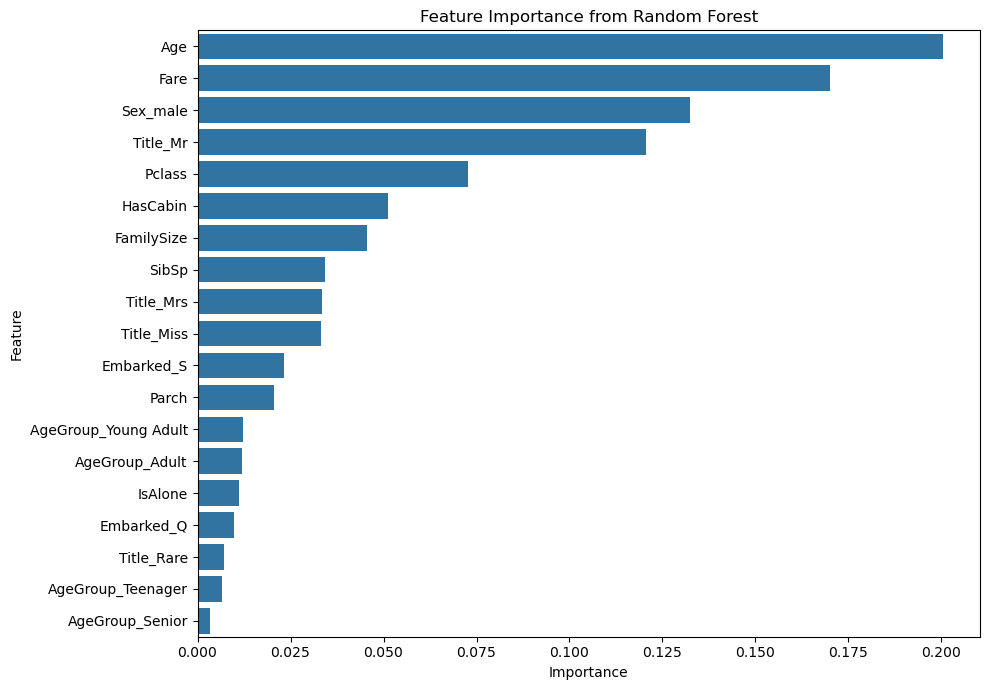

In [184]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("Feature_Importance_Chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [185]:
selected_features = [
    "Age",
    "Fare",
    "Sex_male",
    "Title_Mr",
    "Pclass",
    "HasCabin",
    "FamilySize",
    "SibSp",
    "Title_Mrs",
    "Title_Miss",
    "Embarked_S",
    "Parch"
]

# This is selected based on the importance shown to us by the Random Forest Classifier. 
# Importance lower than 0.02 should be neglected for now to compare the model before and after feature selection

In [186]:
# Scaling the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [187]:
# Creating and Training the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [188]:
# Making Predictions on the scaled test data
y_pred = logistic_model.predict(X_test_scaled)

In [189]:
# predicted probabilities on the scaled test data
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [190]:
# Evaluating the baseline model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Baseline Logistic Regression Results")
print("-------------------------------------")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Baseline Logistic Regression Results
-------------------------------------
Accuracy: 0.8324022346368715
Precision: 0.8
Recall: 0.7536231884057971
F1 Score: 0.7761194029850746
ROC-AUC: 0.8758234519104084


In [191]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[97 13]
 [17 52]]


In [192]:
# Using the selected features
X_selected = X[selected_features]

In [193]:
# Splitting 
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [194]:
# Scaling
scaler_selected = StandardScaler()

X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

In [195]:
# Creating and Training the model with the selected features
selected_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

selected_model.fit(X_train_selected_scaled, y_train_selected)

LogisticRegression(max_iter=1000, random_state=42)

In [196]:
# Making predictions
y_pred_selected = selected_model.predict(X_test_selected_scaled)
y_prob_selected = selected_model.predict_proba(X_test_selected_scaled)[:, 1]

In [197]:
# Evaluating the baseline model using the selected feature
print("Feature-Selected Logistic Regression Results")
print("---------------------------------------------")
print("Accuracy:", accuracy_score(y_test_selected, y_pred_selected))
print("Precision:", precision_score(y_test_selected, y_pred_selected))
print("Recall:", recall_score(y_test_selected, y_pred_selected))
print("F1 Score:", f1_score(y_test_selected, y_pred_selected))
print("ROC-AUC:", roc_auc_score(y_test_selected, y_prob_selected))

Feature-Selected Logistic Regression Results
---------------------------------------------
Accuracy: 0.8156424581005587
Precision: 0.7727272727272727
Recall: 0.7391304347826086
F1 Score: 0.7555555555555555
ROC-AUC: 0.862779973649539


### Feature Selection Decision

Although Random Forest feature importance identified 12 relatively important features, the Logistic Regression model performed better when all 19 features were retained. The model using all 19 features achieved higher Accuracy, Precision, Recall, F1 Score, and ROC-AUC than the model using the selected 12 features. Therefore, all 19 features will be retained for further model optimization, as the lower-ranked features may still provide useful information when combined with other predictors.

## HyperParameter Tuning

In [198]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

In [199]:
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [200]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy')

In [201]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross-Validation Score:
0.8188614202698711


#### Evaluating tuned model

In [202]:
# Fittintg the model with the best parameters
best_model = grid_search.best_estimator_

In [203]:
# Making predictions
y_pred_tuned = best_model.predict(X_test_scaled)

In [204]:
# predicted probabilities
y_prob_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

In [205]:
print("Tuned Logistic Regression Results")
print("----------------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))

Tuned Logistic Regression Results
----------------------------------
Accuracy: 0.8156424581005587
Precision: 0.7903225806451613
Recall: 0.7101449275362319
F1 Score: 0.7480916030534351
ROC-AUC: 0.8659420289855072


In [206]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Confusion Matrix:")
print(cm_tuned)

Confusion Matrix:
[[97 13]
 [20 49]]


### Model Performance Evaluation 

In [207]:
# Creating the performace comparison table

performance_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_tuned)
    ]
})

performance_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.832402,0.800000,0.753623,0.776119,0.875823
1,Tuned Logistic Regression,0.815642,0.790323,0.710145,0.748092,0.865942


In [208]:
performance_display = performance_comparison.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

performance_display[metrics] = (
    performance_display[metrics] * 100
).round(2)

performance_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,83.24,80.00,75.36,77.61,87.58
1,Tuned Logistic Regression,81.56,79.03,71.01,74.81,86.59


### Performance Evaluation

The baseline Logistic Regression model achieved the best overall performance, with an accuracy of 83.24%, precision of 80.00%, recall of 75.36%, F1 score of 77.61%, and ROC-AUC of 87.58%.

Although GridSearchCV identified an optimized parameter combination, the tuned model performed slightly worse on the test set across all evaluation metrics. Its accuracy decreased to 81.56%, while its ROC-AUC decreased from 87.58% to 86.59%.

These results indicate that hyperparameter tuning did not improve the model's generalization performance for this dataset. Therefore, the baseline Logistic Regression model using all 19 features was retained as the best-performing model in this experiment.

### Visualisatons

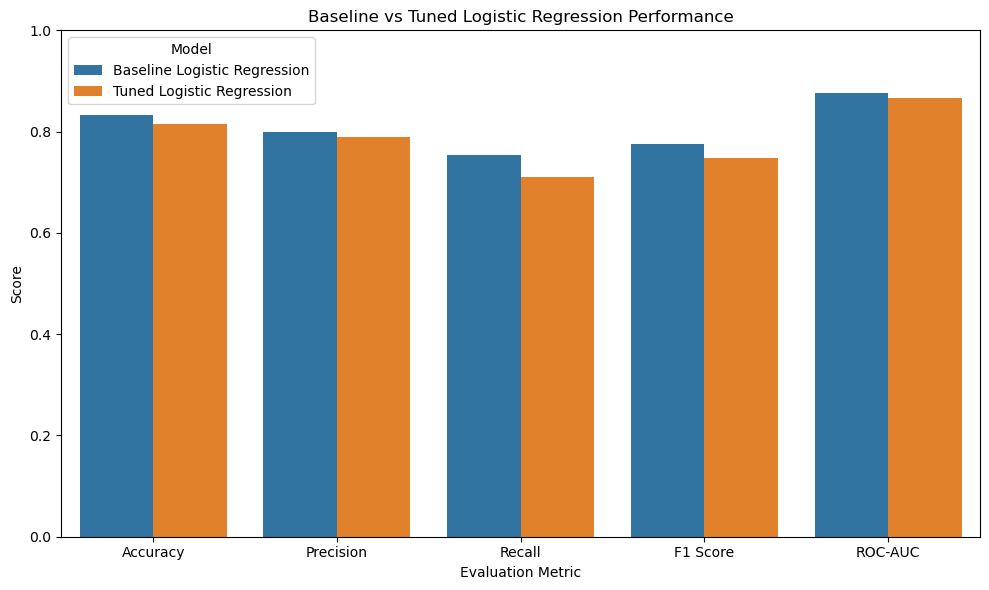

In [209]:
plt.figure(figsize=(10, 6))

performance_plot = performance_comparison.copy()

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

performance_plot = performance_plot.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=performance_plot,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Baseline vs Tuned Logistic Regression Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig("baseline_vs_tuned_logistic_regression.png", dpi=300, bbox_inches="tight")

plt.show()

### Performance Comparison Visualization

The chart compares the baseline and tuned Logistic Regression models across Accuracy, Precision, Recall, F1 Score, and ROC-AUC. The baseline model consistently outperformed the tuned model across all evaluation metrics. This indicates that the original model configuration provided better performance on the test data, while the hyperparameter tuning did not lead to improved generalization in this experiment.

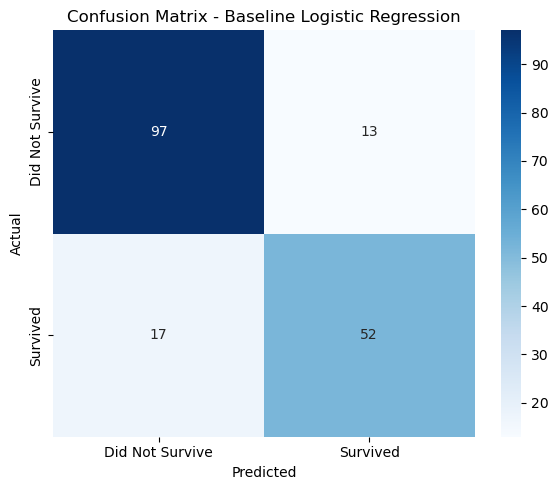

In [210]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig("baseline_logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Saving the model

For this I'd be saving the baseline model with all of the 19 features because it gave us the best accuracy score

In [214]:
jb.dump(
    logistic_model,
    "final_titanic_logistic_regression.pkl"
)

['final_titanic_logistic_regression.pkl']

In [216]:
jb.dump(
    grid_search.best_estimator_,
    "optimized_logistic_regression.pkl"
)

['optimized_logistic_regression.pkl']